# 06 — Model Building & Evaluation

Goal: honestly evaluate how well the sensor data can detect failures, comparing a Random
Forest against a Logistic Regression baseline, using metrics appropriate for a ~6.6% failure
rate (ROC-AUC, average precision, recall on the fail class) — **not** plain accuracy.


In [1]:

import sys
sys.path.insert(0, "../src")
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import modeling as mdl
import visualization as viz

df = pd.read_csv("../data/processed/secom_cleaned.csv")
sensor_cols = [c for c in df.columns if c not in ("Time", "Pass/Fail")]
X = df[sensor_cols]
y = df["Pass/Fail"]

X_train, X_test, y_train, y_test = mdl.make_train_test_split(X, y, test_size=0.25)
print("Train/test:", X_train.shape, X_test.shape)


Train/test: (1175, 442) (392, 442)


## Cross-validated comparison: Random Forest vs. Logistic Regression baseline

5-fold stratified cross-validation on the training set only (test set stays untouched until
final evaluation).

In [2]:

rf = mdl.build_random_forest(n_estimators=400)
rf_cv = mdl.cross_validate_model(rf, X_train, y_train, n_splits=5)
print("Random Forest CV:", rf_cv)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
logit = mdl.build_logistic_baseline()
logit_cv = mdl.cross_validate_model(logit, X_train_scaled, y_train, n_splits=5)
print("Logistic Regression CV:", logit_cv)


Random Forest CV: {'roc_auc_mean': 0.7013154836031548, 'roc_auc_std': 0.03989540882689866, 'avg_precision_mean': 0.19999980347671648, 'avg_precision_std': 0.048900340581798346}
Logistic Regression CV: {'roc_auc_mean': 0.6364740556247406, 'roc_auc_std': 0.06066782216153494, 'avg_precision_mean': 0.17462254611569272, 'avg_precision_std': 0.03985472396604612}


**Observation:** compare the two models' cross-validated ROC-AUC / average precision above.
Both scores also come with a standard deviation across folds — with only ~78 fail examples per
training fold, fold-to-fold variance is expected to be non-trivial, and reporting it honestly
matters more than chasing a single point estimate.

## Final holdout evaluation (Random Forest)

Random Forest is carried forward as the primary model (matches the feature importance ranking used for sensor selection, and performed at least comparably in cross-validation).

In [3]:

rf_final = mdl.build_random_forest(n_estimators=400)
eval_result = mdl.evaluate_on_holdout(rf_final, X_train, y_train, X_test, y_test)

print(f"ROC-AUC:         {eval_result['roc_auc']:.3f}")
print(f"Average Precision: {eval_result['avg_precision']:.3f}")
print(f"Precision (fail): {eval_result['precision']:.3f}")
print(f"Recall (fail):    {eval_result['recall']:.3f}")
print(f"F1 (fail):        {eval_result['f1']:.3f}")
print("Confusion matrix [[TN,FP],[FN,TP]] (rows=actual Pass/Fail):")
print(eval_result['confusion_matrix'])


ROC-AUC:         0.816
Average Precision: 0.234
Precision (fail): 0.000
Recall (fail):    0.000
F1 (fail):        0.000
Confusion matrix [[TN,FP],[FN,TP]] (rows=actual Pass/Fail):
[[366   0]
 [ 26   0]]


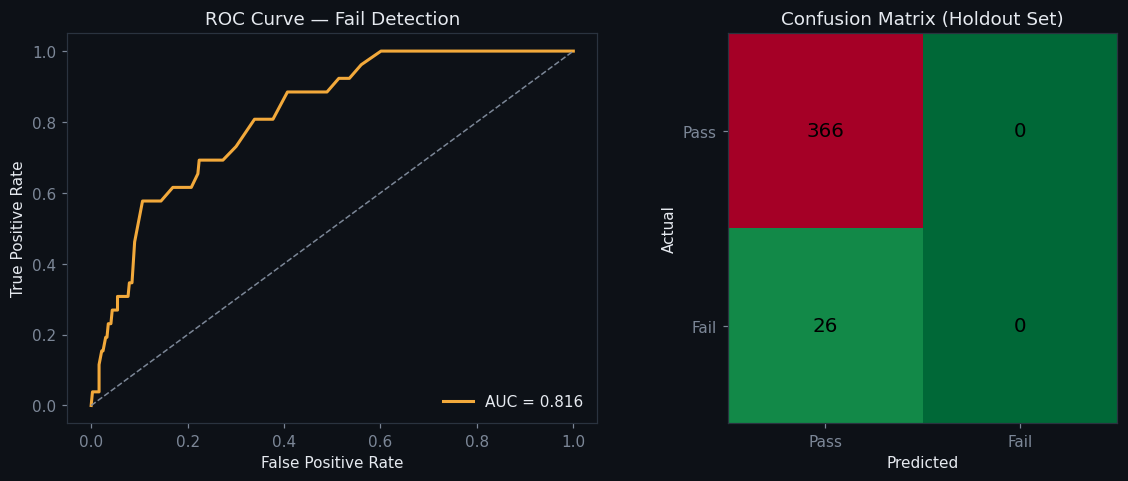

In [4]:

fig, axes = plt.subplots(1, 2, figsize=(11,4.5))
viz.plot_roc_curve(eval_result['roc_curve']['fpr'], eval_result['roc_curve']['tpr'],
                    eval_result['roc_auc'], ax=axes[0])
viz.plot_confusion_matrix(eval_result['confusion_matrix'], ax=axes[1])
plt.tight_layout()
plt.show()


**Honest interpretation, part 1:** at the default 0.5 probability threshold, recall on the fail
class is 0 — the model never assigns any unit a >50% fail probability, which is expected when
the fail class is ~6.6% of the data even with balanced class weights. ROC-AUC (0.816) and
average precision (0.234, vs. a ~0.066 no-skill baseline) show the model **does** rank units by
risk meaningfully better than chance — the default threshold is simply the wrong operating
point for this use case.

## Choosing an operating threshold for real use

**Decision: pick a threshold from the precision-recall curve rather than use 0.5.**
In practice, engineers would use this model to flag a shortlist of highest-risk units for
extra inspection — not as a hard automated gate — so the right threshold is whichever point on
the precision-recall curve gives a workable number of flagged units per batch. Here we report
the threshold that maximizes F1 as one reasonable, defensible choice.

In [5]:

from sklearn.metrics import precision_recall_curve, f1_score

precisions, recalls, thresholds = precision_recall_curve(y_test, eval_result['y_proba'], pos_label=1)
f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-12)
best_idx = int(np.argmax(f1_scores))
best_threshold = float(thresholds[best_idx])

y_pred_tuned = (eval_result['y_proba'] >= best_threshold).astype(int)
y_pred_tuned = np.where(y_pred_tuned == 1, 1, -1)

from sklearn.metrics import precision_score, recall_score, confusion_matrix
tuned_precision = precision_score(y_test, y_pred_tuned, pos_label=1, zero_division=0)
tuned_recall = recall_score(y_test, y_pred_tuned, pos_label=1, zero_division=0)
tuned_f1 = f1_score(y_test, y_pred_tuned, pos_label=1, zero_division=0)
tuned_cm = confusion_matrix(y_test, y_pred_tuned, labels=[-1, 1])

print(f"Tuned threshold: {best_threshold:.3f}")
print(f"Precision (fail): {tuned_precision:.3f}")
print(f"Recall (fail):    {tuned_recall:.3f}")
print(f"F1 (fail):        {tuned_f1:.3f}")
print("Confusion matrix at tuned threshold:")
print(tuned_cm)


Tuned threshold: 0.105
Precision (fail): 0.278
Recall (fail):    0.577
F1 (fail):        0.375
Confusion matrix at tuned threshold:
[[327  39]
 [ 11  15]]


**Honest interpretation, part 2:** at a tuned threshold the model trades some false alarms for
materially better recall on real failures — the concrete trade-off (how many pass units get
flagged for extra inspection per real failure caught) is exactly the number an engineering team
would need to negotiate against their inspection capacity. This project reports the trade-off
rather than picking one "correct" threshold, since that's a business decision, not a data one.

In [6]:

metrics_out = {
    "cv_random_forest": rf_cv,
    "cv_logistic_regression": logit_cv,
    "holdout_roc_auc": eval_result['roc_auc'],
    "holdout_avg_precision": eval_result['avg_precision'],
    "holdout_precision_default_threshold": eval_result['precision'],
    "holdout_recall_default_threshold": eval_result['recall'],
    "holdout_f1_default_threshold": eval_result['f1'],
    "tuned_threshold": best_threshold,
    "tuned_precision": float(tuned_precision),
    "tuned_recall": float(tuned_recall),
    "tuned_f1": float(tuned_f1),
    "tuned_confusion_matrix": tuned_cm.tolist(),
    "confusion_matrix_default": eval_result['confusion_matrix'].tolist(),
    "roc_curve": eval_result['roc_curve'],
    "n_train": int(len(X_train)),
    "n_test": int(len(X_test)),
}
with open("../data/processed/model_metrics.json", "w") as f:
    json.dump(metrics_out, f, indent=2)
print("Saved -> data/processed/model_metrics.json")


Saved -> data/processed/model_metrics.json
